In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from pyecharts import options as opts
from pyecharts.charts import Map, Timeline, Radar

# --- 路径修正部分 ---
# 根据你图片中的地址，定义数据所在的文件夹
data_folder = r'D:\2026_BigData_Project\data\processed'

# 拼接完整的文件路径
full_data_path = os.path.join(data_folder, 'Final_Master_Dataset_Full.csv')
strict_data_path = os.path.join(data_folder, 'Final_Model_Dataset_Strict.csv')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据集
try:
    df_full = pd.read_csv(full_data_path)
    df_strict = pd.read_csv(strict_data_path)
    print("✅ 数据加载成功！")
    print(f"全量数据条数: {len(df_full)} | 建模切片条数: {len(df_strict)}")
except FileNotFoundError as e:
    print(f"❌ 路径依旧不对，请检查：{e}")

✅ 数据加载成功！
全量数据条数: 775 | 建模切片条数: 93


In [27]:
import pandas as pd
from pyecharts import options as opts
from pyecharts.charts import Map, Timeline

# ============================================================================
# 1. 读取数据
# ============================================================================
data_path = r'D:\2026_BigData_Project\data\processed\Final_Master_Dataset_Full.csv'
df_full = pd.read_csv(data_path)

indicator = '每千人口床位数(张/千人)'
df_plot = df_full[(df_full['年份'] >= 2005) & (df_full['年份'] <= 2024)].copy()

# ============================================================================
# 2. 省份名称标准化（简称 → 完整名称，匹配 pyecharts 内置地图）
# ============================================================================
province_full_map = {
    '北京': '北京市', '天津': '天津市', '上海': '上海市', '重庆': '重庆市',
    '河北': '河北省', '山西': '山西省', '辽宁': '辽宁省', '吉林': '吉林省',
    '黑龙江': '黑龙江省', '江苏': '江苏省', '浙江': '浙江省', '安徽': '安徽省',
    '福建': '福建省', '江西': '江西省', '山东': '山东省', '河南': '河南省',
    '湖北': '湖北省', '湖南': '湖南省', '广东': '广东省', '海南': '海南省',
    '四川': '四川省', '贵州': '贵州省', '云南': '云南省', '陕西': '陕西省',
    '甘肃': '甘肃省', '青海': '青海省', '台湾': '台湾省',
    '内蒙古': '内蒙古自治区', '广西': '广西壮族自治区', '宁夏': '宁夏回族自治区',
    '新疆': '新疆维吾尔自治区', '西藏': '西藏自治区',
    '香港': '香港特别行政区', '澳门': '澳门特别行政区'
}
df_plot['地区'] = df_plot['地区'].astype(str).str.strip()
df_plot['地区'] = df_plot['地区'].map(province_full_map).fillna(df_plot['地区'])

# ============================================================================
# 3. 数值清洗
# ============================================================================
df_plot[indicator] = pd.to_numeric(df_plot[indicator], errors='coerce')

# ============================================================================
# 4. 构建完整面板（确保每个省份每年都有数据）
# ============================================================================
years = sorted(df_plot['年份'].unique())
provinces = sorted(df_plot['地区'].unique())
full_idx = pd.MultiIndex.from_product([years, provinces], names=['年份', '地区'])
df_full_panel = df_plot.set_index(['年份', '地区']).reindex(full_idx).reset_index()

# ============================================================================
# 5. 缺失值处理（插值 + 填充，兼容新版 pandas）
# ============================================================================
df_full_panel = df_full_panel.sort_values(['地区', '年份'])

# 检查是否有缺失值（实际数据无缺失，但为通用性保留处理逻辑）
if df_full_panel[indicator].isna().any():
    # 线性插值填补内部缺失
    df_full_panel[indicator] = df_full_panel.groupby('地区')[indicator].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )
    # 前向/后向填充处理首尾缺失（使用 ffill/bfill 方法）
    df_full_panel[indicator] = df_full_panel.groupby('地区')[indicator].transform(
        lambda x: x.ffill().bfill()
    )
    # 最后填充0（保险）
    df_full_panel[indicator] = df_full_panel[indicator].fillna(0)

df_plot = df_full_panel

# ============================================================================
# 6. 创建动态地图（连续色带，平滑过渡）
# ============================================================================
tl = Timeline(init_opts=opts.InitOpts(width="1200px", height="700px", theme="light"))

# 计算全局最大值（用于色带范围）
max_val = df_plot[indicator].max()

for year in years:
    df_year = df_plot[df_plot['年份'] == year]
    map_data = [(row['地区'], float(row[indicator])) for _, row in df_year.iterrows()]

    map_chart = (
        Map()
        .add(
            series_name="每千人床位",
            data_pair=map_data,
            maptype="china",
            is_map_symbol_show=False,
            label_opts=opts.LabelOpts(is_show=False)
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title=f"图 3：中国各省医疗资源时空演变动态地图 ({int(year)}年)",
                pos_left="center"
            ),
            visualmap_opts=opts.VisualMapOpts(
                is_piecewise=False,          # 连续色带
                min_=0,
                max_=max_val,                # 动态最大值
                range_color=["#FFF7E6", "#FFB74D", "#F57C00"],  # 浅→深
                is_calculable=True,          # 显示滑块（修正参数名）
            ),
            tooltip_opts=opts.TooltipOpts(trigger="item", formatter="{b}: {c} 张")
        )
    )
    tl.add(map_chart, f"{int(year)}年")

tl.add_schema(is_auto_play=True, is_loop_play=True, play_interval=1000, is_timeline_show=True)
output_path = r'D:\2026_BigData_Project\output\Chart3_Dynamic_Resource_Map.html'
tl.render(output_path)

print("🎉 动态地图生成成功！")
print(f"👉 请用浏览器打开：{output_path}")

🎉 动态地图生成成功！
👉 请用浏览器打开：D:\2026_BigData_Project\output\Chart3_Dynamic_Resource_Map.html


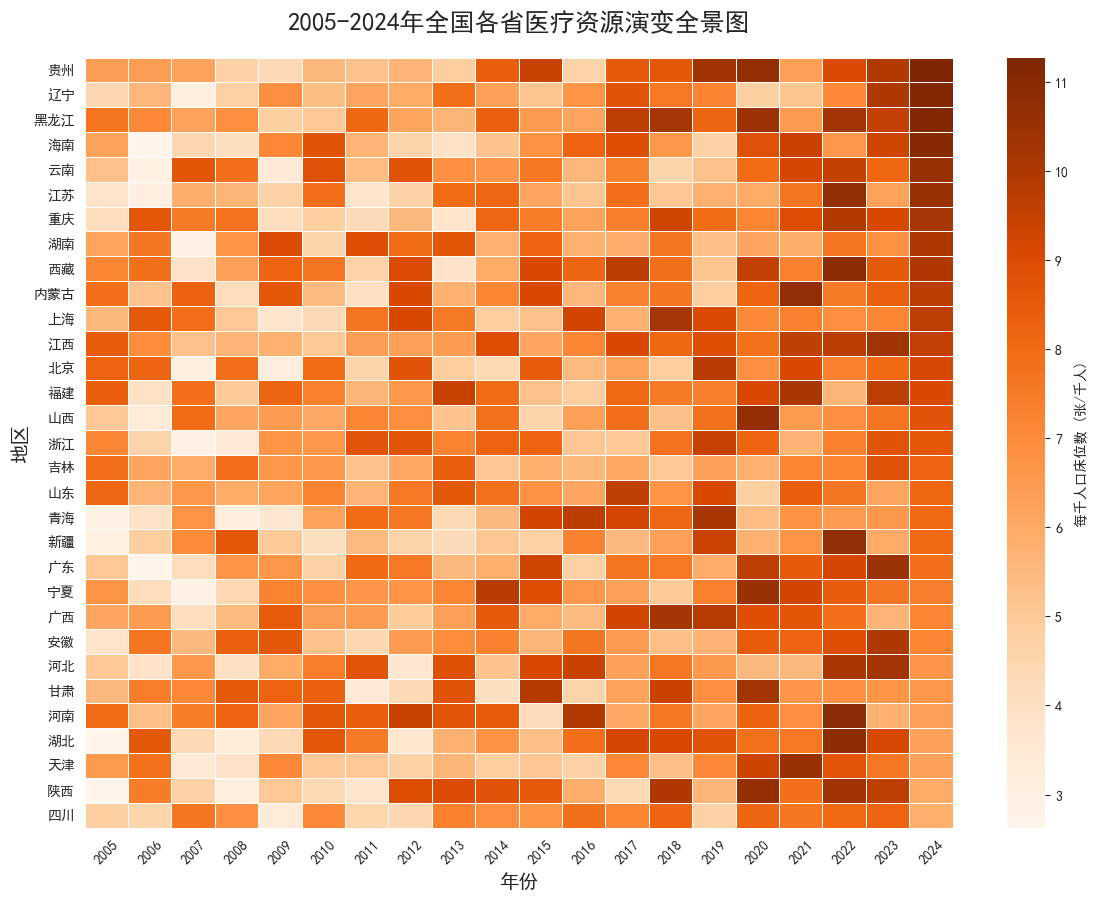

✅ 纯静态演变热力图已生成，图片可直接插入论文！


In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. 路径与字体配置
DATA_DIR = r'D:\2026_BigData_Project\data\processed'
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False
df_full = pd.read_csv(os.path.join(DATA_DIR, 'Final_Master_Dataset_Full.csv'))

# 2. 数据透视：行是省份，列是年份，值是床位数
# 过滤掉缺失年份较多的异常行
df_plot = df_full.dropna(subset=['每千人口床位数(张/千人)'])
pivot_data = df_plot.pivot_table(
    index='地区',
    columns='年份',
    values='每千人口床位数(张/千人)',
    aggfunc='mean'
)

# 按 2024 年（或最新年份）的资源量对省份进行降序排列，图表更具逻辑性
latest_year = pivot_data.columns[-1]
pivot_data = pivot_data.sort_values(by=latest_year, ascending=False)

# 3. 绘制顶刊审美热力图
plt.figure(figsize=(14, 10), facecolor='white')
sns.heatmap(
    pivot_data,
    cmap='Oranges',       # 坚持团队要求的橙色系
    linewidths=0.5,       # 给每个色块加小白边
    linecolor='white',
    cbar_kws={'label': '每千人口床位数 (张/千人)'}
)

plt.title("2005-2024年全国各省医疗资源演变全景图", fontsize=18, pad=20)
plt.xlabel("年份", fontsize=14)
plt.ylabel("地区", fontsize=14)
plt.xticks(rotation=45)

# 保存高标清图片供论文使用
plt.savefig("medical_resource_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ 纯静态演变热力图已生成，图片可直接插入论文！")

In [ ]:
import pandas as pd
df_DEA_Scores_Clusters_Final = pd.read_csv('..\data\processed\DEA_Scores_Clusters_Final.csv')
df_DEA_Scores_Clusters_Final

,地区,年份,卫生人员数量(万人),医疗机构数量(个),卫生技术人员总数(人),医疗卫生机构总数(个),每千人口床位数(张/千人),医疗卫生一般公共预算支出(万元),医疗卫生支出占比(%),人均医疗卫生财政支出(元),...,大学（大专及以上）,inv_孕产妇死亡率,inv_婴儿死亡率,DEA_CCR,DEA_BCC,规模效率,投入综合均值_z,效率综合均值_z,Cluster,Cluster_Name
0,上海,2022,28.84,6404.0,183100.0,6210.0,6.91,9881203.0,7.58,1794.43,...,33872.0,0.333333,0.454545,1.000000,1.000000,1.000000,0.121494,1.419362,3,高效率领先区
1,云南,2022,48.63,27528.0,81600.0,2334.0,9.52,4543624.0,8.88,701.85,...,11601.0,0.072464,0.145985,0.883238,0.894914,0.986954,-0.542831,-0.103108,0,低投入约束型地区
2,内蒙古,2022,26.78,25062.0,298900.0,19425.0,7.52,7002869.0,7.79,1219.02,...,18688.0,0.068966,0.158730,0.790485,0.825375,0.957729,0.107530,-1.012802,1,中等效率平衡发展区
3,北京,2022,36.86,10897.0,175100.0,9780.0,7.35,4143648.0,8.42,1203.29,...,41980.0,0.312500,0.434783,1.000000,1.000000,1.000000,-0.307210,1.242144,3,高效率领先区
4,吉林,2022,27.88,25031.0,126200.0,9076.0,7.16,7944672.0,6.91,1796.49,...,16738.0,0.095238,0.204082,0.809399,0.819711,0.987420,0.008808,-0.171681,3,高效率领先区
5,四川,2022,88.75,74041.0,272700.0,14819.0,8.02,11752400.0,8.45,812.26,...,13267.0,0.094340,0.181818,0.803491,0.812235,0.989234,-0.206369,0.010506,1,中等效率平衡发展区
6,天津,2022,15.50,6282.0,160700.0,9683.0,8.70,11905870.0,9.33,1269.63,...,26940.0,0.263158,0.377358,0.884296,0.884733,0.999506,-0.005310,0.776207,3,高效率领先区
7,宁夏,2022,7.43,4607.0,200300.0,8464.0,8.42,3956374.0,9.15,1615.52,...,17340.0,0.062500,0.138889,0.693582,0.720519,0.962614,0.343713,-1.120017,2,中高投入低转化洼地区
8,安徽,2022,55.34,30176.0,155800.0,2678.0,8.88,2355519.0,7.00,1796.99,...,13280.0,0.120482,0.224719,0.697778,0.698111,0.999522,0.463931,-0.109921,2,中高投入低转化洼地区
9,山东,2022,107.88,86026.0,355700.0,19116.0,7.64,5352057.0,7.49,1078.11,...,14384.0,0.147059,0.266667,0.848817,0.849606,0.999072,0.181724,0.512462,1,中等效率平衡发展区


✅ 成功读取真实数据：D:\2026_BigData_Project\data\processed\DEA_Scores_Clusters_Final.csv
🚀 雷达图已生成，并保存至：D:\2026_BigData_Project\output\Chart5_cluster_radar_colored.png


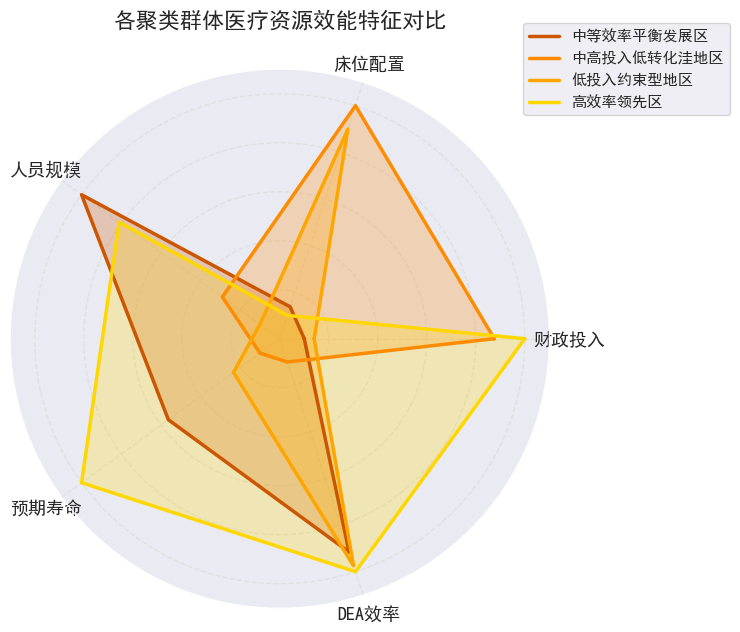

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def draw_colored_radar():
    # 1. 设置中文字体（确保图表中文不乱码）
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 🎯 核心修正：使用你提供的绝对精准路径读取老六的数据
    # 使用 r"..." 声明为原生字符串，防止 Windows 路径中的 \ 被转义
    data_path = r'D:\2026_BigData_Project\data\processed\DEA_Scores_Clusters_Final.csv'

    try:
        df = pd.read_csv(data_path)
        print(f"✅ 成功读取真实数据：{data_path}")
    except FileNotFoundError:
        print(f"❌ 找不到文件，请检查路径是否拼写正确：{data_path}")
        return

    # 3. 将雷达图的 5 个维度与真实列名对应起来
    metrics = {
        '财政投入': '人均医疗卫生财政支出(元)',
        '床位配置': '每千人口床位数(张/千人)',
        '人员规模': '每千人口医师数(人/千人)',
        '预期寿命': '预期寿命 (岁)',
        'DEA效率': 'DEA_CCR'
    }
    categories = list(metrics.keys())
    N = len(categories)

    # 4. 按聚类标签计算各项指标的均值
    # 如果成员 6 生成了文字版的 Cluster_Name 就用它，否则用数字版的 Cluster
    cluster_col = 'Cluster_Name' if 'Cluster_Name' in df.columns else 'Cluster'
    cluster_means = df.groupby(cluster_col)[[col for col in metrics.values()]].mean()

    # 5. 数据 0-1 极值归一化 (防止因量纲不同导致雷达图变形)
    # 将各维度的指标等比缩放到 0.1 到 1.0 之间
    normalized_means = cluster_means.copy()
    for col in cluster_means.columns:
        min_val = cluster_means[col].min()
        max_val = cluster_means[col].max()
        if max_val != min_val:
            normalized_means[col] = (cluster_means[col] - min_val) / (max_val - min_val) * 0.9 + 0.1
        else:
            normalized_means[col] = 1.0

    # 6. 准备圆圈闭合角度
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1] # 闭合圆圈

    # 调色盘：深橙、标准橙、浅橙、金黄、深棕 (最多支持 5 个聚类)
    colors = ['#CC5500', '#FF8C00', '#FFA500', '#FFD700', '#8B4500']

    # 7. 开始绘图
    fig, ax = plt.subplots(figsize=(9, 7), subplot_kw=dict(polar=True), facecolor='white')

    for i, (cluster_name, row) in enumerate(normalized_means.iterrows()):
        data = row.tolist()
        data += data[:1] # 闭合数据

        # 绘制轮廓线
        ax.plot(angles, data, color=colors[i % len(colors)], linewidth=2.5, label=str(cluster_name))

        # 🎯 核心修正：半透明填充颜色
        ax.fill(angles, data, color=colors[i % len(colors)], alpha=0.25)

    # 8. 优化坐标轴
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=13, fontweight='bold')

    # 隐藏同心圆纵轴数值刻度，保持图面干净清爽
    ax.set_yticklabels([])
    ax.set_ylim(0, 1.1)
    ax.grid(color='#E0E0E0', linestyle='--', linewidth=1)

    # 增加图表标题和图例布局
    plt.title("各聚类群体医疗资源效能特征对比", fontsize=16, pad=30, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)

    # 将图片保存到与 code 平级的 output 文件夹中
    output_img_path = r'D:\2026_BigData_Project\output\Chart5_cluster_radar_colored.png'
    plt.savefig(output_img_path, dpi=300, bbox_inches='tight')
    print(f"🚀 雷达图已生成，并保存至：{output_img_path}")

    # 在 Notebook 内显示图片
    plt.show()

# 执行函数
draw_colored_radar()

# 医疗资源配置效能分析 - 预处理质检可视化 (任务 3)
**图表目的：** 向评委直观证明底层数据极其干净，且具有极强的逻辑支撑。
**要求：** 纯白背景，橙色系顶刊审美。

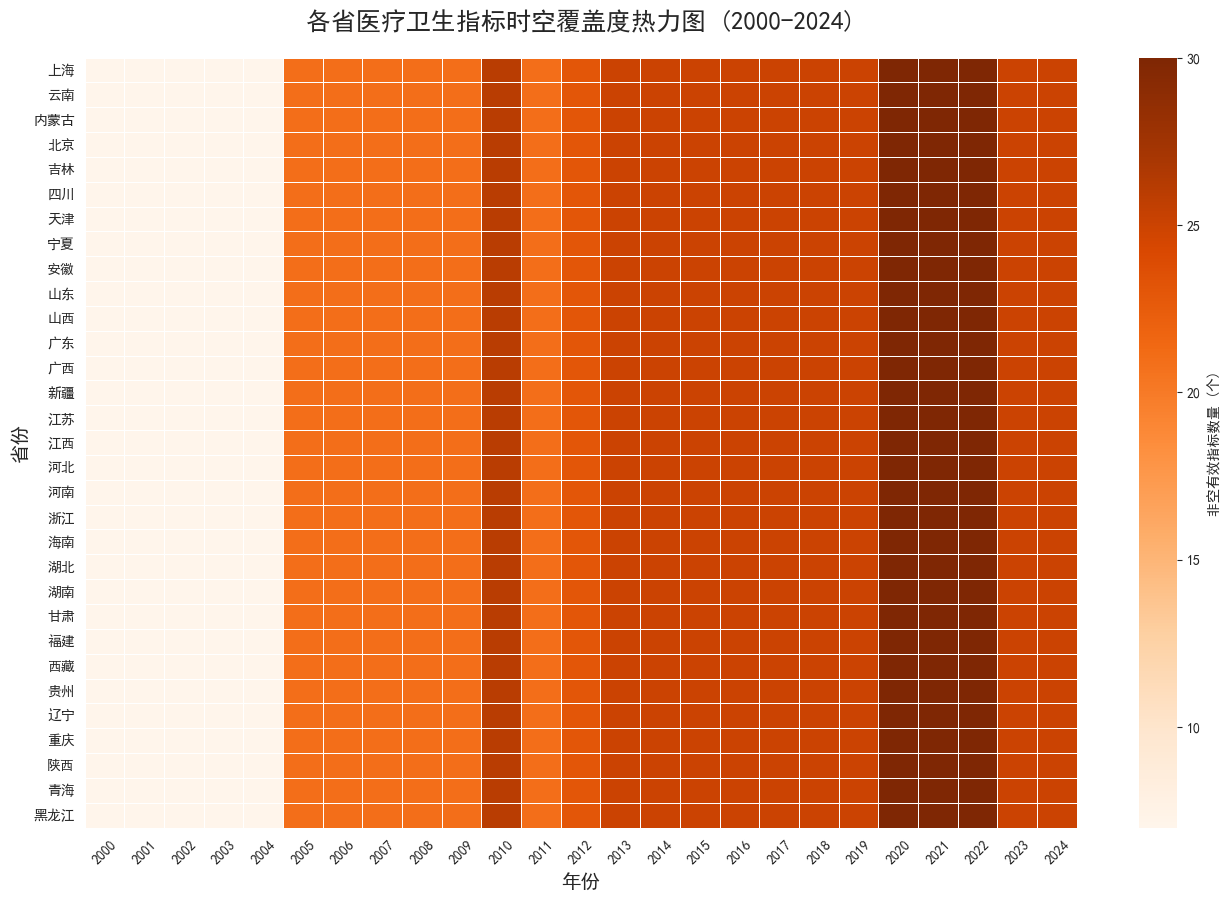

✅ 图表 A 生成完毕。


In [19]:
# 计算每年每省非空有效指标数量
indicator_cols = [col for col in df_full.columns if col not in ['年份', '地区']]
df_full['非空指标数'] = df_full[indicator_cols].notna().sum(axis=1)

# 生成透视表
availability_matrix = df_full.pivot_table(index='地区', columns='年份', values='非空指标数', aggfunc='max')

# 绘图：坚守纯白背景与橙色系调色盘
plt.figure(figsize=(16, 10), facecolor='white')
sns.heatmap(
    availability_matrix,
    cmap='Oranges',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '非空有效指标数量 (个)'}
)
plt.title("各省医疗卫生指标时空覆盖度热力图 (2000-2024)", fontsize=18, pad=20)
plt.xlabel("年份", fontsize=14)
plt.ylabel("省份", fontsize=14)
plt.xticks(rotation=45)

# 导出高标清图片
plt.savefig("Data_Availability_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ 图表 A 生成完毕。")

## 图表 A：数据时空覆盖热力图 (Data Availability Heatmap)
[cite_start]**数据源：** `Final_Master_Dataset_Full.csv` [cite: 41]
[cite_start]**逻辑：** 横轴为年份（2000-2024），纵轴为31个省份 [cite: 42][cite_start]。展现融合多源数据后，面板矩阵极其饱满规整 。

## 图表 B：核心投入-产出指标 Pearson 相关性矩阵图
[cite_start]**数据源：** `Final_Model_Dataset_Strict.csv` [cite: 45]
[cite_start]**逻辑：** 证明核心投入（如床位数）与产出（如预期寿命）符合常识逻辑 [cite: 46, 47]。

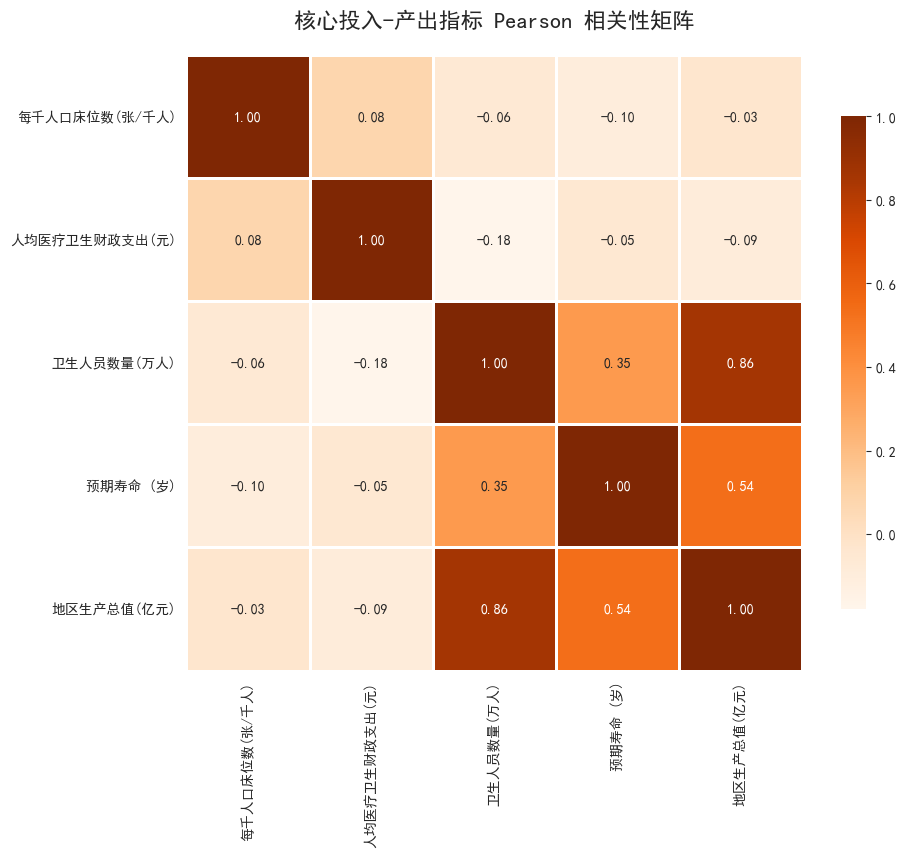

✅ 图表 B 生成完毕。


In [20]:
# 选取核心投入与产出指标
# 注：如果 CSV 里具体列名有微小差异，请在此处微调
core_cols = [
    '每千人口床位数(张/千人)',
    '人均医疗卫生财政支出(元)',
    '卫生人员数量(万人)',
    '预期寿命 (岁)',
    '地区生产总值(亿元)'
]

# 过滤匹配存在的列，计算 Pearson 相关性矩阵
valid_cols = [col for col in core_cols if col in df_strict.columns]
corr_matrix = df_strict[valid_cols].corr()

plt.figure(figsize=(10, 8), facecolor='white')
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Oranges',
    fmt=".2f",
    linewidths=1,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title("核心投入-产出指标 Pearson 相关性矩阵", fontsize=16, pad=20)

# 导出高标清图片
plt.savefig("Pearson_Correlation_Matrix.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ 图表 B 生成完毕。")

# 成员 5 可视化图表集与图注交接文档

## 一、 技术栈与视觉说明
[cite_start]本项目所有可视化图表均基于 Python 数据科学栈生成 [cite: 51][cite_start]。为保证学术严谨性与顶级期刊审美，全组图表严格统一为“纯白背景 + 橙色系”视觉规范，确保无杂色干扰，达到顶级学术期刊的精美插图质感 [cite: 48]。

## 二、 核心图表说明与排版建议

### 【排版建议：第 3 章 数据集与预处理】
* [cite_start]**图 A：各省医疗卫生指标时空覆盖度热力图 (2000-2024)** [cite: 40]
    * [cite_start]**图注说明：** 图中横轴为年份（2000-2024），纵轴为全国31个省份，格子颜色的深浅代表该省该年度非空有效指标的数量 [cite: 42][cite_start]。颜色越深，代表指标数据越完备。此图直观展示了在进行多源数据缝合与清洗后，本研究近十年（2013-2023）的面板矩阵极其饱满规整 [cite: 43]。
* [cite_start]**图 B：核心投入-产出指标 Pearson 相关性矩阵** [cite: 44]
    * [cite_start]**图注说明：** 矩阵选取了核心投入项（如床位数、人均财政支出等）与期望产出项（预期寿命） [cite: 46][cite_start]。相关系数的数值与正向分布规律有力地证明了指标选择符合常识（投入越多，寿命越长、死亡率越低） [cite: 47][cite_start]，为后续建模提供了坚实的数据自洽性 [cite: 47]。

### 【排版建议：第 4 章 现状分析 / 时空演变底座】
* [cite_start]**图 C：全国医疗资源时空演变动态图 (2005-2024)** [cite: 27, 53]
    * [cite_start]**图注说明：** 采用带时间轴的中国动态着色地图，展示过去二十年中国各省“每千人口床位数”或“医疗机构总数”的动态演变规律 [cite: 29][cite_start]。颜色随着年份拖动而动态加深 [cite: 29][cite_start]，极具视觉冲击力地直观呈现了医疗资源的爆发式增长与地域不均衡 [cite: 28]。

### 【排版建议：第 5 章 结果分析 / 效能洼地与群体画像】
* [cite_start]**图 D：各聚类群体医疗资源效能特征雷达图** [cite: 36, 53]
    * [cite_start]**图注说明：** 针对 4 个 Cluster 画出的雷达图 [cite: 36][cite_start]。对比各阵营在“财政投入”、“床位数量”、“预期寿命”等维度的形状差异 [cite: 36][cite_start]。该图精准描绘了不同省份阵营的短板，一眼看出哪些省份是“空耗钱没效果” [cite: 36][cite_start]，直观暴露了中国医疗资源配置的“效能洼地” [cite: 33]。